In [1]:
import matplotlib.pyplot as plt
import pandas as pd
#import metapredict as meta
from pysam import FastaFile
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.ExPASy import ScanProsite
from quantiprot.utils.io import load_fasta_file
from quantiprot.utils.feature import Feature, FeatureSet
from quantiprot.metrics.aaindex import get_aa2charge, get_aa2hydropathy, get_aa2volume
from quantiprot.utils.mapping import simplify
from quantiprot.metrics.basic import identity, average, sum_absolute, uniq_count
from quantiprot.utils.sequence import compact
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils.ProtParam import ProtParamData
from sklearn.metrics import roc_curve, roc_auc_score
from sparrow import Protein
from scipy.stats import mannwhitneyu
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import numpy as np
#import metapredict as meta

In [2]:
def calculate_auc_with_ci(df, column, label, random_state=42):
    np.random.seed(random_state)  # Set the seed for reproducibility
    
    aucs = []
    pr_aucs = []
    max_f1_scores = []  
    fprs = []  # False Positive Rate
    n_bootstrap = 200
    
    for _ in range(n_bootstrap):
        # Separate the data into positive and negative classes
        positive = df[df[label] == 1]
        negative = df[df[label] == 0]
        min_size = min(len(positive), len(negative))
        positive_resampled = resample(positive, replace=False, n_samples=min_size)
        negative_resampled = resample(negative, replace=False, n_samples=min_size)
        sample = pd.concat([positive_resampled, negative_resampled])
        sample = resample(sample, replace=True)
        sample = sample.dropna(subset=[label, column])
        if sample.empty:
            continue
        try:
            # Calculate AUC and PR AUC
            auc = roc_auc_score(sample[label], sample[column])
            aucs.append(auc)
            pr_auc = average_precision_score(sample[label], sample[column])
            pr_aucs.append(pr_auc)
            
            # Calculate FPR, TPR, and F1 Score at thresholds
            fpr, tpr, thresholds = roc_curve(sample[label], sample[column])
            specificity = 1 - fpr
            f1_scores_at_thresholds = 2 * (tpr * specificity) / (tpr + specificity + 1e-10)  
            max_f1_index = np.argmax(f1_scores_at_thresholds)
            max_f1 = f1_scores_at_thresholds[max_f1_index]
            max_f1_scores.append(max_f1)
            
            # Calculate False Positive Rate (FPR) at max F1 threshold
            fprs.append(fpr[max_f1_index])  # Store FPR at the threshold where F1 is maximized
            
        except ValueError:
            pass
    
    # Calculate Confidence Intervals for metrics
    auc_ci = t.interval(0.95, len(aucs) - 1, loc=np.mean(aucs), scale=sem(aucs))
    pr_auc_ci = t.interval(0.95, len(pr_aucs) - 1, loc=np.mean(pr_aucs), scale=sem(pr_aucs))
    max_f1_ci = t.interval(0.95, len(max_f1_scores) - 1, loc=np.mean(max_f1_scores), scale=sem(max_f1_scores))
    fpr_ci = t.interval(0.95, len(fprs) - 1, loc=np.mean(fprs), scale=sem(fprs))

    return (
        np.mean(aucs), auc_ci,
        np.mean(pr_aucs), pr_auc_ci,
        np.mean(max_f1_scores), max_f1_ci,
        np.mean(fprs), fpr_ci
    )

In [3]:
class get_seq(object):
    def __init__(self, seq, ref, alt, start, pos):
        self.seq =  seq
        self.size = len(self.seq)
        self.index = int(pos) -1
        self.start = int(start)
        self.ref =  ref
        self.alt = alt
        self.ref_size = len(self.ref)
        
    def __iter__(self):
        return self

    def get_ref(self):
        ref_index = self.index - self.start
        print(ref_index)
        str_ref = self.seq[ref_index]
        if str(str_ref) == str(self.ref):
            return True
        else:
            print("Warning: fasta sequence base {0} does not match the input {1} for seq {2} for index {3}".format(str_ref,
                                                                                                          self.ref,
                                                                                                         self.seq, self.index))
    
    def generate_mutant(self):
        #check_ref = self.get_ref()
        pos = self.index - self.start
        mut_seq = str(self.seq[:pos +1]) + str(self.alt) + str(self.seq[pos + 2:])
        #print(self.seq)
        #print(mut_seq)
        return mut_seq

    def generate_del(self):
        mut_seq =  str(self.seq[:self.index + 1]) + str(self.seq[self.index + self.ref_size :])
        return mut_seq

In [4]:
#mutation_data_df = pd.read_csv("../output/AF2_Disorder_deleterious_neutral_vus_results_filtered.tsv", sep='\t')
mutation_data_df = pd.read_csv("../alphafold/AF2_Disorder_deleterious_neutral_vus_results.tsv", sep='\t')
fasta_dir = '/projects/wangc/rohan/missense_prediction/disorder/disorder/alphafold/fasta_download'
mutation_data_df['mutation'] = mutation_data_df['CAVA_PROTREF'] + mutation_data_df['CAVA_PROTPOS'].astype(str) + mutation_data_df['CAVA_PROTALT']
mutation_vus_df = mutation_data_df[mutation_data_df['Class'] == 'VUS']
mutation_data_df = mutation_data_df[mutation_data_df['Class'] != 'VUS']

drop_genes = ['STING1', 'PRDM2', 'PEX5', 'ITGB2', 'NOTCH1', 'PTEN']
mutation_data_df = mutation_data_df[~mutation_data_df['GENES'].isin(drop_genes)]
mutation_vus_df = mutation_vus_df[~mutation_vus_df['GENES'].isin(drop_genes)]
mutation_data_df = mutation_data_df.groupby(['mutation', 'GENES', 'Class']).first().reset_index()
mutation_vus_df = mutation_vus_df.groupby(['mutation', 'GENES', 'Class']).first().reset_index()
mutation_vus_df

,mutation,GENES,Class,CAVA_CSN,CAVA_PROTALT,CAVA_PROTPOS,CAVA_PROTREF,CAVA_TRANSCRIPT,CLNSIG,CLNREVSTAT,CLNHGVS,UNIPROT_ID_x,CHROM,GSTART,GEND,TRANSCRIPT_x,TRANSCRIPT_NOV,UNIPROT_ID_y,within_interval
0,A1001T,ABL1,VUS,c.3001G>A_p.Ala1001Thr,T,1001,A,NM_005157.6,Uncertain_significance,"criteria_provided,_single_submitter",NC_000009.11:g.133760678G>A,P00519,chr9,515,1024,NM_005157.6,NM_005157,P00519,True
1,A1001V,ABL1,VUS,c.3002C>T_p.Ala1001Val,V,1001,A,NM_005157.6,Uncertain_significance,"criteria_provided,_multiple_submitters,_no_con...",NC_000009.11:g.133760679C>T,P00519,chr9,515,1024,NM_005157.6,NM_005157,P00519,True
2,A1003P,DOT1L,VUS,c.3007G>C_p.Ala1003Pro,P,1003,A,NM_032482.3,Uncertain_significance,"criteria_provided,_single_submitter",NC_000019.9:g.2222175G>C,Q8TEK3,chr19,647,1537,NM_032482.3,NM_032482,Q8TEK3,True
3,A1005D,MET,VUS,c.3014C>A_p.Ala1005Asp,D,1005,A,NM_000245.4,Uncertain_significance,"criteria_provided,_single_submitter",NC_000007.13:g.116412029C>A,P08581,chr7,934,1053,NM_000245.4,NM_000245,P08581,True
4,A1005T,MET,VUS,c.3013G>A_p.Ala1005Thr,T,1005,A,NM_000245.4,Uncertain_significance,"criteria_provided,_single_submitter",NC_000007.13:g.116412028G>A,P08581,chr7,934,1053,NM_000245.4,NM_000245,P08581,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13204,Y931C,ROBO3,VUS,c.2792A>G_p.Tyr931Cys,C,931,Y,NM_022370.4,Uncertain_significance,"criteria_provided,_single_submitter",NC_000011.9:g.124747069A>G,Q96MS0,chr11,864,1386,NM_022370.4,NM_022370,Q96MS0,True
13205,Y966C,TSC1,VUS,c.2897A>G_p.Tyr966Cys,C,966,Y,NM_000368.5,Uncertain_significance,"criteria_provided,_multiple_submitters,_no_con...",NC_000009.11:g.135772649T>C,Q92574,chr9,964,1164,NM_000368.5,NM_000368,Q92574,True
13206,Y971C,MET,VUS,c.2912A>G_p.Tyr971Cys,C,971,Y,NM_000245.4,Uncertain_significance,"criteria_provided,_single_submitter",NC_000007.13:g.116411927A>G,P08581,chr7,934,1053,NM_000245.4,NM_000245,P08581,True
13207,Y971F,MET,VUS,c.2912A>T_p.Tyr971Phe,F,971,Y,NM_000245.4,Uncertain_significance,"criteria_provided,_single_submitter",NC_000007.13:g.116411927A>T,P08581,chr7,934,1053,NM_000245.4,NM_000245,P08581,True


In [5]:
def load_fasta(fasta, GSTART, GEND):
    fasta_sequences = SeqIO.parse(open(fasta), 'fasta')
    START = GSTART -1
    seq = str(next(fasta_sequences).seq)[START:GEND]
    return seq

def get_wildtype_sequence(row):
    fasta = f"{fasta_dir}/{row['UNIPROT_ID']}.fasta"
    seq = load_fasta(fasta, row['GSTART'], row['GEND'])
    return seq

def get_mutatant_seq(row):
    index = row['CAVA_PROTPOS'] 
    gen_seq = get_seq(row['WT'], row['CAVA_PROTREF'], row['CAVA_PROTALT'], row['GSTART'], index)
    mut_seq = gen_seq.generate_mutant()
    return mut_seq

def get_asphericity(seq):
    p = Protein(seq)
    score = p.predictor.asphericity()
    return score

def get_radius_of_gyration(seq):
    p = Protein(seq)
    score = p.predictor.radius_of_gyration()
    return score

def get_end_to_end_distance(seq):
    p = Protein(seq)
    score = p.predictor.end_to_end_distance()
    return score

def get_scaling_exponent(seq):
    p = Protein(seq)
    score = p.predictor.scaling_exponent()
    return score

def get_prefactor(seq):
    p = Protein(seq)
    score = p.predictor.prefactor()
    return score



In [6]:
data_df  = mutation_data_df[['mutation', 'Class','UNIPROT_ID_x','GENES', 'CHROM', 'GSTART', 'GEND', 'CAVA_PROTALT', 'CAVA_PROTPOS', 'CAVA_PROTREF', 'CAVA_TRANSCRIPT']]
data_df.columns = ['mutation', 'Class','UNIPROT_ID','GENES', 'CHROM', 'GSTART', 'GEND', 'CAVA_PROTALT', 'CAVA_PROTPOS', 'CAVA_PROTREF', 'CAVA_TRANSCRIPT']
data_df['WT'] = data_df.apply(get_wildtype_sequence, axis=1)
data_df['mut_seq'] = data_df.apply(get_mutatant_seq, axis=1)
data_df['wt_asphericity'] = data_df['WT'].apply(lambda x:get_asphericity(x))
data_df['mut_asphericity'] = data_df['mut_seq'].apply(lambda x:get_asphericity(x))
data_df['wt_radius_of_gyration'] = data_df['WT'].apply(lambda x:get_radius_of_gyration(x))
data_df['mut_radius_of_gyration'] = data_df['mut_seq'].apply(lambda x:get_radius_of_gyration(x))
data_df['wt_end_to_end_distance'] = data_df['WT'].apply(lambda x:get_end_to_end_distance(x))
data_df['mut_end_to_end_distance'] = data_df['mut_seq'].apply(lambda x:get_end_to_end_distance(x))
data_df['wt_scaling_exponent'] = data_df['WT'].apply(lambda x:get_scaling_exponent(x))
data_df['mut_scaling_exponent'] = data_df['mut_seq'].apply(lambda x:get_scaling_exponent(x))
data_df['wt_prefactor'] = data_df['WT'].apply(lambda x:get_prefactor(x))
data_df['mut_prefactor'] = data_df['mut_seq'].apply(lambda x:get_prefactor(x))

/tmp/ipykernel_1524331/1479036243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df['WT'] = data_df.apply(get_wildtype_sequence, axis=1)
/tmp/ipykernel_1524331/1479036243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df['mut_seq'] = data_df.apply(get_mutatant_seq, axis=1)


In [7]:
data_df['delta_asphericity'] = data_df['mut_asphericity'] - data_df['wt_asphericity']
data_df['delta_radius_of_gyration'] = data_df['mut_radius_of_gyration'] - data_df['wt_radius_of_gyration']
data_df['delta_end_to_end_distance'] = data_df['mut_end_to_end_distance'] - data_df['wt_end_to_end_distance']
data_df['delta_scaling_exponent'] = data_df['mut_scaling_exponent'] - data_df['wt_scaling_exponent']
data_df['delta_prefactor'] = data_df['mut_prefactor'] - data_df['wt_prefactor']
data_df['abs_delta_asphericity'] = data_df['delta_asphericity'].abs()
data_df['abs_delta_radius_of_gyration'] = data_df['delta_radius_of_gyration'].abs()
data_df['abs_delta_end_to_end_distance'] = data_df['delta_end_to_end_distance'].abs()
data_df['abs_delta_scaling_exponent'] = data_df['delta_scaling_exponent'].abs()
data_df['abs_delta_prefactor'] = data_df['delta_prefactor'].abs()
#data_df.to_csv("AF2_disorder_albertross_prediction_all.tsv", sep='\t', index=None)
data_df.to_csv("../output/AF2_disorder_albertross_prediction_all.tsv", sep='\t', index=None)

In [8]:

data_df = pd.read_csv("../output/AF2_disorder_albertross_prediction_all.tsv", sep='\t')
data_keep_df = data_df[data_df['Class'] != 'VUS']
data_vus_df = data_df[data_df['Class'] == 'VUS']
remove_genes = ['STING1', 'PRDM2', 'PEX5', 'ITGB2', 'NOTCH1', 'PTEN']
data_keep_df = data_keep_df[~data_keep_df['GENES'].isin(remove_genes)]
data_vus_df = data_vus_df[~data_vus_df['GENES'].isin(remove_genes)]
data_keep_df = data_keep_df.groupby(['mutation', 'GENES', 'Class']).first().reset_index()
data_vus_df= data_vus_df.groupby(['mutation', 'GENES', 'Class']).first().reset_index()
#data_keep_df = pd.merge(data_keep_df, mutation_star_df, on='mutation', how='left')
data_keep_df['CLNREVSTAT'] = mutation_data_df['CLNREVSTAT']
#data_vus_df['CLNREVSTAT'] = mutation_data_df['CLNREVSTAT']


data_keep_df.to_csv('../output/AF2_disorder_albatross_features_CLNREVSTAT.csv', index=None)
#data_vus_df.to_csv('../output/AF2_disorder_albatross_VUS_CLNREVSTAT.csv', index=None)


In [9]:
#print(data_keep_df['WT'].iloc[1])


def count_low_disorder_bases(sequence, threshold=50):
    """
    Predicts disorder for a given protein sequence and counts residues with disorder < threshold.
    
    :param sequence: Amino acid sequence (string)
    :param threshold: Disorder score threshold (default 0.5)
    :return: Count of residues with disorder score < threshold
    """
    #disorder_scores = meta.predict_disorder(sequence)
    disorder_scores = meta.predict_pLDDT(sequence)
    #print(disorder_scores)
    low_disorder_count = sum(1 for score in disorder_scores if score < threshold)
    return low_disorder_count

#protein_sequence = "MAEAPPRRLGLGPPPGDAPRAELVALTAVQSEQGEAGGGGSPRRLGLLGSPLPPGAPLPGPGSGSGSACGQRSS"  # Replace with actual protein sequence
#disorder_scores = count_low_disorder_bases(protein_sequence)
#data_keep_df['disorder_check'] = data_keep_df['WT'].apply(lambda x:count_low_disorder_bases(x))

In [10]:
#data_keep_df['size'] = data_keep_df['WT'].astype(str).str.len()
#low_disorder_df = data_keep_df[(data_keep_df['disorder_check']> 1)][['Class','GENES', 'GSTART', 'GEND', 'WT', 'size', 'disorder_check']].drop_duplicates()
#high_disorder_df = data_keep_df[data_keep_df['disorder_check'] <  10]
#low_disorder_df.Class.value_counts()

#data_keep_df[['abs_delta_asphericity', 'abs_delta_radius_of_gyration']]

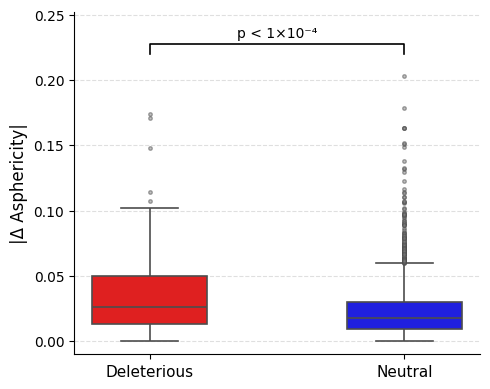

In [11]:
import matplotlib.patches as mpatches

# ── Data preparation ───────────────────────────────────────────────────────────
data_keep_df['scaled_asphericity'] = np.sqrt(data_keep_df['abs_delta_asphericity'])

class_a = data_keep_df[data_keep_df['Class'] == 'Deleterious']['abs_delta_asphericity']
class_b = data_keep_df[data_keep_df['Class'] == 'Neutral']['abs_delta_asphericity']
stat, p_value = mannwhitneyu(class_a, class_b, alternative='two-sided')

# ── Plot ───────────────────────────────────────────────────────────────────────
PALETTE = {'Deleterious': 'red', 'Neutral': 'blue'}

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=data_keep_df,
    x='Class', y='scaled_asphericity',
    order=['Deleterious', 'Neutral'],
    palette=PALETTE,
    width=0.45,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=2.5,
                    markerfacecolor='#888888', alpha=0.5),
    ax=ax,
)

# ── Significance bracket ───────────────────────────────────────────────────────
y_max = data_keep_df['scaled_asphericity'].max()
y_range = y_max - data_keep_df['scaled_asphericity'].min()
bracket_y = y_max + 0.08 * y_range
bracket_h = 0.04 * y_range

ax.plot([0, 0, 1, 1],
        [bracket_y, bracket_y + bracket_h, bracket_y + bracket_h, bracket_y],
        lw=1.2, color='black')

p_text = f'p = {p_value:.2e}' if p_value >= 1e-4 else f'p < 1×10⁻⁴'
ax.text(0.5, bracket_y + bracket_h * 1.3, p_text,
        ha='center', va='bottom', fontsize=10, color='black')

# ── Formatting ─────────────────────────────────────────────────────────────────
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('|Δ Asphericity|', fontsize=12)
ax.set_xticklabels(['Deleterious', 'Neutral'], fontsize=11)
ax.set_ylim(
    data_keep_df['scaled_asphericity'].min() - 0.05 * y_range,
    bracket_y + bracket_h + 0.12 * y_range,
)
ax.tick_params(axis='y', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
sns.despine(ax=ax)

handles = [mpatches.Patch(color=v, label=k) for k, v in PALETTE.items()]
#ax.legend(handles=handles, fontsize=9, framealpha=0.9,
#          loc='upper right', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig('association_asphericity_sqrt.png', dpi=300, bbox_inches='tight')
plt.show()

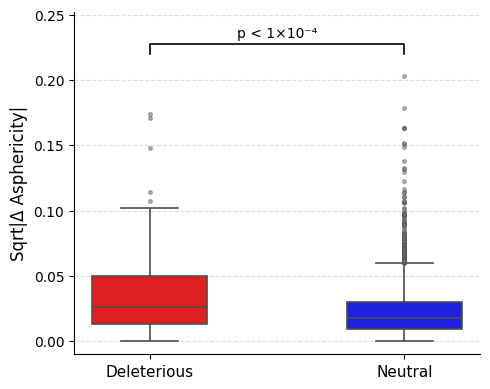

Saved → association_asphericity_sqrt.png  (p = 3.11e-12)


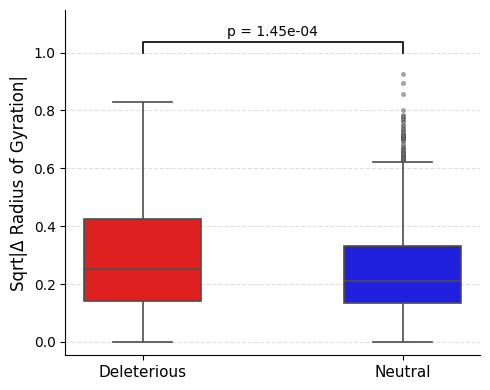

Saved → association_radiusofgyration.png  (p = 1.45e-04)


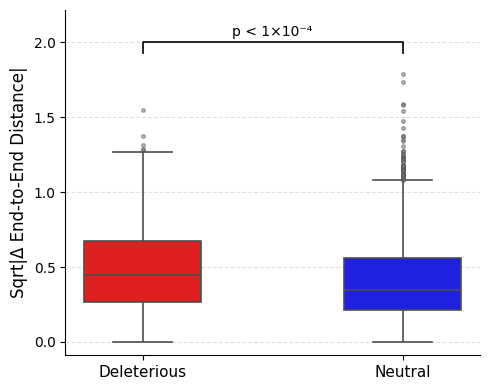

Saved → association_endtoenddistance.png  (p = 1.25e-06)


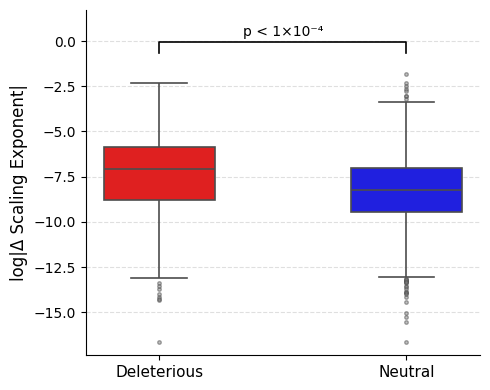

Saved → association_scaling_exponent.png  (p = 2.18e-13)


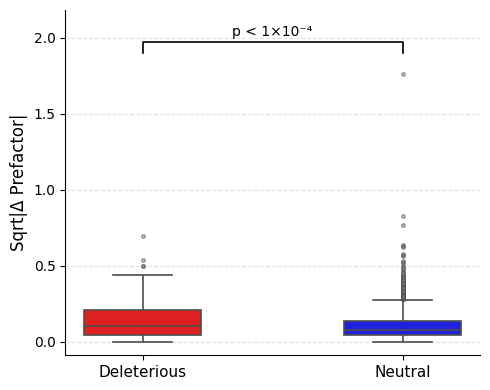

Saved → association_prefactor.png  (p = 3.50e-08)


In [12]:
# Performing the Mann-Whitney U Test

import matplotlib.patches as mpatches

PALETTE = {'Deleterious': 'red', 'Neutral': 'blue'}

def plot_feature_boxplot(df, raw_col, scaled_col, transform, ylabel, outpath):
    """
    Parameters
    ----------
    raw_col   : column used for Mann-Whitney test (untransformed)
    scaled_col: column name to create for plotting
    transform : 'sqrt' or 'log'
    ylabel    : y-axis label string
    outpath   : filename to save
    """
    # Transform
    if transform == 'sqrt':
        df[scaled_col] = np.sqrt(df[raw_col])
        transform_label = f'Sqrt|Δ {ylabel}|'
    else:
        df[scaled_col] = np.log(df[raw_col].replace(0, np.nan))
        transform_label = f'log|Δ {ylabel}|'

    # Mann-Whitney on raw values
    class_a = df[df['Class'] == 'Deleterious'][raw_col].dropna()
    class_b = df[df['Class'] == 'Neutral'][raw_col].dropna()
    _, p_value = mannwhitneyu(class_a, class_b, alternative='two-sided')

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.boxplot(
        data=df,
        x='Class', y=scaled_col,
        order=['Deleterious', 'Neutral'],
        palette=PALETTE,
        width=0.45,
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=2.5,
                        markerfacecolor='#888888', alpha=0.5),
        ax=ax,
    )

    # Significance bracket
    vals = df[scaled_col].dropna()
    y_min, y_max = vals.min(), vals.max()
    y_range     = y_max - y_min
    bracket_y   = y_max + 0.08 * y_range
    bracket_h   = 0.04 * y_range

    ax.plot([0, 0, 1, 1],
            [bracket_y, bracket_y + bracket_h,
             bracket_y + bracket_h, bracket_y],
            lw=1.2, color='black')

    p_text = f'p = {p_value:.2e}' if p_value >= 1e-4 else 'p < 1×10⁻⁴'
    ax.text(0.5, bracket_y + bracket_h * 1.3, p_text,
            ha='center', va='bottom', fontsize=10)

    ax.set_xlabel('', fontsize=12)
    ax.set_ylabel(transform_label, fontsize=12)
    ax.set_xticklabels(['Deleterious', 'Neutral'], fontsize=11)
    ax.set_ylim(y_min - 0.05 * y_range,
                bracket_y + bracket_h + 0.12 * y_range)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

    handles = [mpatches.Patch(color=v, label=k) for k, v in PALETTE.items()]
    #ax.legend(handles=handles, fontsize=9, framealpha=0.9,
    #          loc='upper right', edgecolor='#cccccc')

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {outpath}  (p = {p_value:.2e})")


# ── One call per feature ───────────────────────────────────────────────────────
plot_feature_boxplot(data_keep_df,
    raw_col='abs_delta_asphericity',
    scaled_col='scaled_asphericity',
    transform='sqrt',
    ylabel='Asphericity',
    outpath='association_asphericity_sqrt.png')

plot_feature_boxplot(data_keep_df,
    raw_col='abs_delta_radius_of_gyration',
    scaled_col='scaled_radius_of_gyration',
    transform='sqrt',
    ylabel='Radius of Gyration',
    outpath='association_radiusofgyration.png')

plot_feature_boxplot(data_keep_df,
    raw_col='abs_delta_end_to_end_distance',
    scaled_col='scaled_end_to_end_distance',
    transform='sqrt',
    ylabel='End-to-End Distance',
    outpath='association_endtoenddistance.png')

plot_feature_boxplot(data_keep_df,
    raw_col='abs_delta_scaling_exponent',
    scaled_col='scaled_scaling_exponent',
    transform='log',
    ylabel='Scaling Exponent',
    outpath='association_scaling_exponent.png')


plot_feature_boxplot(data_keep_df,
    raw_col='abs_delta_prefactor',
    scaled_col='scaled_prefactor',
    transform='sqrt',
    ylabel='Prefactor',
    outpath='association_prefactor.png')




['wt_asphericity', 'mut_asphericity', 'wt_radius_of_gyration', 'mut_radius_of_gyration', 'delta_asphericity', 'delta_radius_of_gyration', 'abs_delta_asphericity', 'abs_delta_radius_of_gyration', 'scaled_asphericity', 'scaled_radius_of_gyration']
Using features: []


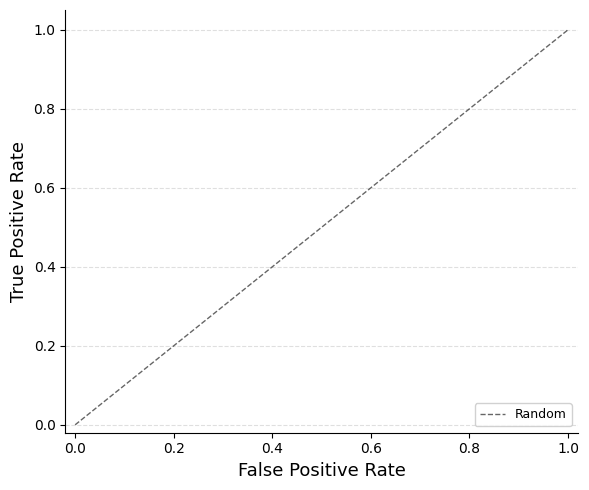

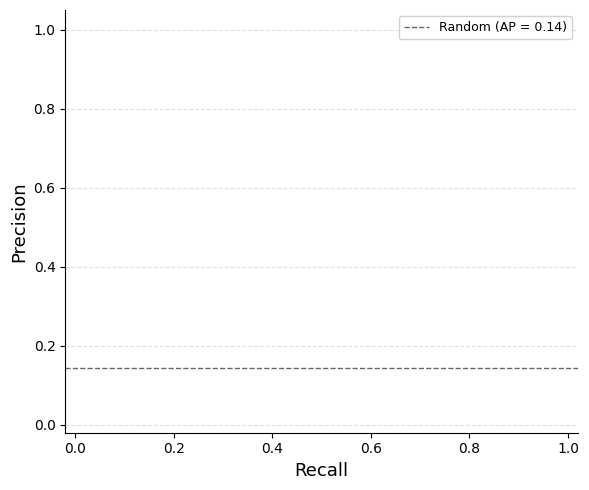

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# ── Use whatever column names currently exist in the dataframe ─────────────────
# Check what's there:
print([c for c in data_keep_df.columns if 'spheric' in c.lower() or 'gyration' in c.lower()])

# Define features using the names that already exist after renaming
features = [
    'asphericity',
    'radius_of_gyration',
    'scaling_exponent',
    'end_to_end_distance',
    'prefactor',
]

# Verify all exist
features = [f for f in features if f in data_keep_df.columns]
missing  = [f for f in features if f not in data_keep_df.columns]
if missing:
    print(f"WARNING: missing columns: {missing}")
print("Using features:", features)

data_keep_df['label'] = data_keep_df['Class'].map({'Deleterious': 1, 'Neutral': 0})

COLORS = ['#E84855', '#457B9D', '#2CA02C', '#FF7F0E', '#9467BD']

def _format_ax(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.tick_params(labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

for feature, color in zip(features, COLORS):
    y_true  = data_keep_df['label']
    y_score = data_keep_df[feature]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f'{display_names[feature]}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.6, label='Random')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
_format_ax(ax, 'False Positive Rate', 'True Positive Rate')
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#cccccc', loc='lower right')
plt.tight_layout()
plt.savefig('figure_gIDRc_roc_auc.png', dpi=300, bbox_inches='tight')
plt.show()

# ── PR-AUC ────────────────────────────────────────────────────────────────────
baseline = data_keep_df['label'].mean()

fig, ax = plt.subplots(figsize=(6, 5))

for feature, color in zip(features, COLORS):
    y_true  = data_keep_df['label']
    y_score = data_keep_df[feature]
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax.plot(rec, prec, color=color, linewidth=1.8,
            label=f'{display_names[feature]}  (AP = {ap:.3f})')

ax.axhline(baseline, color='black', linestyle='--', linewidth=1.0,
           alpha=0.6, label=f'Random (AP = {baseline:.2f})')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
_format_ax(ax, 'Recall', 'Precision')
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#cccccc', loc='upper right')
plt.tight_layout()
plt.savefig('figure_gIDRc_pr_auc.png', dpi=300, bbox_inches='tight')
plt.show()

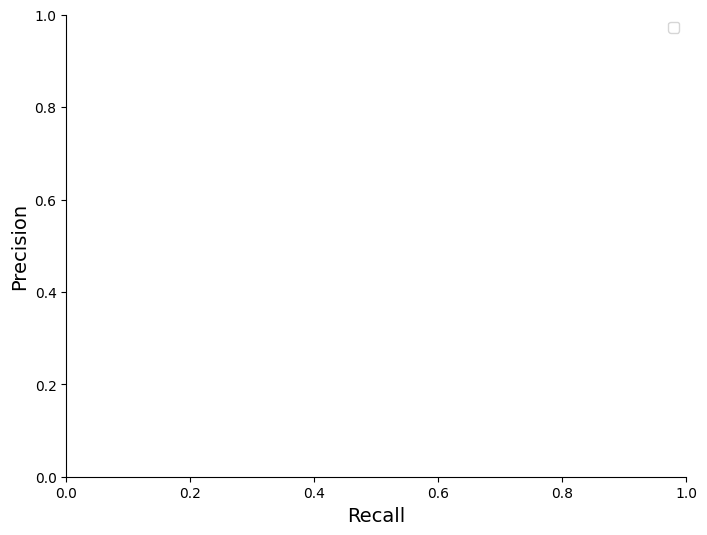

In [14]:
from sklearn.metrics import precision_recall_curve, auc
plt.figure(figsize=(8, 6))

for feature in features:
    true_labels = data_keep_df['label']  # Replace 'Class' with the binary label column
    predicted_probs = data_keep_df[feature]
    
    # Compute Precision-Recall curve and AUC-PR
    precision, recall, _ = precision_recall_curve(true_labels, predicted_probs)
    pr_auc = auc(recall, precision)
    
    # Plot Precision-Recall curve
    plt.plot(recall, precision, label=f'{feature} (AUC-PR = {pr_auc:.4f})')

# Plot settings
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision',fontsize=14)
plt.legend(loc='upper right')  # Moved legend to top right
sns.despine()
plt.savefig("AUCPR_of_pidrc.png", dpi=300)
plt.show()

In [15]:
data_chrom_genes_df = data_df[['CHROM', 'GENES']]
data_chrom_genes_df = data_chrom_genes_df.drop_duplicates()
data_chrom_genes_df.to_csv("AF2_disorder_genes_chrom.tsv", sep='\t', index=None)

In [16]:
data_df.to_csv('../output/AF2_disorder_albatross_features.csv', index=None)
data_df

,mutation,Class,UNIPROT_ID,GENES,CHROM,GSTART,GEND,CAVA_PROTALT,CAVA_PROTPOS,CAVA_PROTREF,...,delta_asphericity,delta_radius_of_gyration,delta_end_to_end_distance,delta_scaling_exponent,delta_prefactor,abs_delta_asphericity,abs_delta_radius_of_gyration,abs_delta_end_to_end_distance,abs_delta_scaling_exponent,abs_delta_prefactor
0,A1011E,Neutral,Q92574,TSC1,chr9,964,1164,E,1011,A,...,-0.000456,0.017019,0.131157,-6.663799e-04,0.004899,0.000456,0.017019,0.131157,6.663799e-04,0.004899
1,A102T,Neutral,Q01094,E2F1,chr20,1,129,T,102,A,...,-0.000393,0.013588,0.058448,8.940697e-07,0.006736,0.000393,0.013588,0.058448,8.940697e-07,0.006736
2,A1034T,Neutral,P10071,GLI3,chr7,946,1580,T,1034,A,...,-0.000208,0.005750,0.008303,4.893541e-05,0.000582,0.000208,0.005750,0.008303,4.893541e-05,0.000582
3,A1039T,Neutral,P10071,GLI3,chr7,946,1580,T,1039,A,...,-0.000060,0.015651,0.013494,-1.955032e-05,0.001185,0.000060,0.015651,0.013494,1.955032e-05,0.001185
4,A103V,Neutral,Q9H9B1,EHMT1,chr9,1,523,V,103,A,...,-0.000043,0.013189,0.062245,1.219511e-04,-0.001080,0.000043,0.013189,0.062245,1.219511e-04,0.001080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2198,Y828C,Deleterious,P01130,LDLR,chr19,720,860,C,828,Y,...,0.001576,0.275188,0.814735,2.996266e-03,-0.092376,0.001576,0.275188,0.814735,2.996266e-03,0.092376
2199,Y828H,Deleterious,P01130,LDLR,chr19,720,860,H,828,Y,...,0.001318,0.192311,0.475619,1.688719e-03,-0.054022,0.001318,0.192311,0.475619,1.688719e-03,0.054022
2200,Y828S,Deleterious,P01130,LDLR,chr19,720,860,S,828,Y,...,0.001424,0.276003,0.796044,2.910852e-03,-0.087781,0.001424,0.276003,0.796044,2.910852e-03,0.087781
2201,Y856H,Neutral,P38398,BRCA1,chr17,103,1396,H,856,Y,...,0.000180,0.254660,0.531156,2.546907e-04,-0.005212,0.000180,0.254660,0.531156,2.546907e-04,0.005212


In [17]:
ref_list = list(set(data_df.WT.tolist()))
with open('disorder_ref_seq.list', 'w+') as fout:
    for i in ref_list:
        fout.write(i + '\n')

In [18]:
mut_list = list(set(data_df.mut_seq.tolist()))

with open('disorder_mut_seq.list', 'w+') as fout:
    for i in mut_list:
        fout.write(i + '\n')
#data_df.columns